# 02 - Three-Node Entanglement Swapping

## Objetivo
Demonstrar entrelaçamento fim a fim em uma cadeia linear `a - r - b`, onde
`r` gera entrelaçamento elementar com os dois vizinhos e realiza o swap,
comparando a estimativa de fidelidade do `IntentPlanner` com a fidelidade
realmente observada na simulação.

## Conceitos
- Topologia:

```text
a ---- r ---- b
```

  `r` é o único nó repetidor; `a` e `b` são os extremos do intent.
- `planning.feasibility.estimate_swap_only_fidelity` estima a fidelidade
  fim a fim com a fórmula fechada do swap de estados Bell-diagonais
  (`ibqn.physics.bds_swap_fidelity`), um porte literal de
  `EntanglementSwappingA_BDS.swapping_res` do SeQUeNCe - nunca uma física
  inventada (`docs/physical_model.md`). Com portas e medições ideais (o
  padrão desta topologia de demonstração), o parâmetro de Werner
  `w = (4F - 1)/3` dos dois pares se multiplica.
- Enquanto um par elementar espera na memória pelo outro enlace, ele
  decoere (canal despolarizante, tempo de coerência de 1 s por padrão):
  a fidelidade entregue fica um pouco abaixo da fórmula fechada e varia
  de par para par.
- A fidelidade *observada* vem exclusivamente de eventos `DELIVERY` reais
  (`docs/assurance_design.md`), nunca da estimativa do planner.


## Configuração


In [1]:
from ibqn.demos.topologies import three_node_spec
from ibqn.network.sequence_adapter import SequenceAdapter
from ibqn.network.capabilities import NetworkCapabilities
from ibqn.execution.sequence_executor import SequenceExecutor
from ibqn.intent.repository import IntentRepository
from ibqn.intent.models import (
    EntanglementIntent, IntentEndpoints, IntentRequirements, IntentValidation, SuccessCondition,
)
from ibqn.planning.planner import IntentPlanner

SEED = 0
REQUESTED_PAIRS = 10
MIN_FIDELITY = 0.65  # below the single-swap ceiling -> no purification needed (see notebook 03)
RAW_FIDELITY = 0.85

spec = three_node_spec(
    end_memories=REQUESTED_PAIRS, repeater_memories=REQUESTED_PAIRS * 2,
    raw_fidelity=RAW_FIDELITY,
)

intent = EntanglementIntent(
    id="intent-three-node-demo",
    endpoints=IntentEndpoints(source="a", destination="b"),
    requirements=IntentRequirements(
        min_fidelity=MIN_FIDELITY, min_throughput=1, max_latency=1.0,
        requested_pairs=REQUESTED_PAIRS, start_time=0.02, duration=0.1,
    ),
    validation=IntentValidation(
        metrics=["delivered_pairs", "average_fidelity"],
        success_conditions=[
            SuccessCondition(metric="delivered_pairs", operator=">=", expected=REQUESTED_PAIRS),
            SuccessCondition(metric="average_fidelity", operator=">=", expected=MIN_FIDELITY),
        ],
    ),
)
print("a ---- r ---- b  (r = repeater/swap node)")
intent


2026-10-02 15:03:07,055 INFO     ibqn.ibqn.intent.models intent_id=- - IntentRequirements: migrating legacy field 'requested_pairs' -> 'reserved_memory_slots' (see docs/intent_resource_semantics.md)


2026-10-02 15:03:07,062 INFO     ibqn.ibqn.intent.models intent_id=- - IntentRequirements: migrating legacy field 'start_time' -> 'start_time_s' (see docs/intent_resource_semantics.md)


2026-10-02 15:03:07,064 INFO     ibqn.ibqn.intent.models intent_id=- - IntentRequirements: migrating legacy field 'duration' -> 'duration_s' (see docs/intent_resource_semantics.md)


a ---- r ---- b  (r = repeater/swap node)


EntanglementIntent(id='intent-three-node-demo', service='entanglement_distribution', endpoints=IntentEndpoints(source='a', destination='b'), requirements=IntentRequirements(min_fidelity=0.65, min_throughput=1.0, max_latency=1.0, min_delivered_pairs=None, reserved_memory_slots=10, start_time_s=0.02, duration_s=0.1), policy=IntentPolicy(priority='normal', allow_rerouting=True, allow_purification=True, allow_multiple_paths=False), validation=IntentValidation(metrics=['delivered_pairs', 'average_fidelity'], success_conditions=[SuccessCondition(metric='delivered_pairs', operator='>=', expected=10.0), SuccessCondition(metric='average_fidelity', operator='>=', expected=0.65)]))

## Execução

O `IntentPlanner` decide a rota e estima a fidelidade *antes* de qualquer simulação rodar.


In [2]:
capabilities = NetworkCapabilities(spec)
planner = IntentPlanner(capabilities)
plan = planner.plan(intent)

print(f"route: {' -> '.join(plan.route)}")
print(f"estimated end-to-end fidelity (planner, pre-simulation): {plan.estimated_metrics.fidelity:.4f}")
print(f"requires_purification: {plan.requires_purification}")


2026-10-02 15:03:07,098 INFO     ibqn.ibqn.planning.planner intent_id=intent-three-node-demo - planned route a->r->b, estimated_fidelity=0.7300, purification=False


route: a -> r -> b
estimated end-to-end fidelity (planner, pre-simulation): 0.7300
requires_purification: False


In [3]:
adapter = SequenceAdapter(spec, seed=SEED)
repository = IntentRepository()
executor = SequenceExecutor(adapter, repository)

executor.deploy(intent, plan)
executor.run()

repository.get(intent.id).lifecycle.status


2026-10-02 15:03:07,142 INFO     ibqn.ibqn.network.sequence_adapter intent_id=- - topology built: 3 routers, 2 quantum links, formalism=bell_diagonal, seed=0


2026-10-02 15:03:07,144 INFO     ibqn.ibqn.intent.repository intent_id=intent-three-node-demo - intent registered


2026-10-02 15:03:07,146 INFO     ibqn.ibqn.intent.repository intent_id=intent-three-node-demo - intent transitioned to VALIDATED (schema validated)


2026-10-02 15:03:07,147 INFO     ibqn.ibqn.intent.repository intent_id=intent-three-node-demo - intent transitioned to PLANNING (invoking IntentPlanner)


2026-10-02 15:03:07,148 INFO     ibqn.ibqn.intent.repository intent_id=intent-three-node-demo - intent transitioned to PLANNED (selected by ShortestHopCountRouting; hop fidelities [0.85, 0.85])


2026-10-02 15:03:07,150 INFO     ibqn.ibqn.intent.repository intent_id=intent-three-node-demo - intent transitioned to DEPLOYING (applying route a->r->b and submitting reservation to NetworkManager (purification_mode=until_target))


2026-10-02 15:03:07,151 INFO     ibqn.ibqn.execution.sequence_executor intent_id=intent-three-node-demo - submitting reservation a -> b, reserved_memory_slots=10, min_fidelity=0.650, purification_mode=until_target


2026-10-02 15:03:07,153 INFO     ibqn.ibqn.network.sequence_adapter intent_id=- - running simulation, stop_time=0.200s


2026-10-02 15:03:07,156 INFO     ibqn.ibqn.intent.repository intent_id=intent-three-node-demo - intent transitioned to ACTIVE (reservation approved)


<IntentStatus.ACTIVE: 'ACTIVE'>

## Resultados


In [4]:
from ibqn.assurance.telemetry import collect_intent_evidence
from ibqn.demos.tables import delivered_pairs_table

evidence = collect_intent_evidence(intent)
pairs_df = delivered_pairs_table(evidence)
observed_avg_fidelity = pairs_df["fidelity"].mean()

print(f"delivered pairs: {len(evidence.delivered_pairs)} (requested: {REQUESTED_PAIRS})")
print(f"planner-estimated end-to-end fidelity : {plan.estimated_metrics.fidelity:.4f}")
print(f"observed end-to-end fidelity (mean)    : {observed_avg_fidelity:.4f}")
print(f"elementary (per-hop) fidelity          : {RAW_FIDELITY:.4f}  <- higher: no swap yet")
pairs_df.head(10)


delivered pairs: 665 (requested: 10)
planner-estimated end-to-end fidelity : 0.7300
observed end-to-end fidelity (mean)    : 0.7288
elementary (per-hop) fidelity          : 0.8500  <- higher: no swap yet


,pair,local_memory,remote_memory,delivery_time_s,fidelity
0,1,a.MemoryArray[0],b.MemoryArray[3],0.020753,0.729098
1,2,a.MemoryArray[1],b.MemoryArray[5],0.021205,0.728971
2,3,a.MemoryArray[4],b.MemoryArray[0],0.021658,0.727944
3,4,a.MemoryArray[5],b.MemoryArray[4],0.021658,0.728393
4,5,a.MemoryArray[8],b.MemoryArray[8],0.021658,0.727944
5,6,a.MemoryArray[7],b.MemoryArray[3],0.021858,0.729038
6,7,a.MemoryArray[2],b.MemoryArray[6],0.022110,0.729165
7,8,a.MemoryArray[6],b.MemoryArray[5],0.022310,0.728910
8,9,a.MemoryArray[0],b.MemoryArray[0],0.022310,0.728071
9,10,a.MemoryArray[4],b.MemoryArray[1],0.022663,0.729031


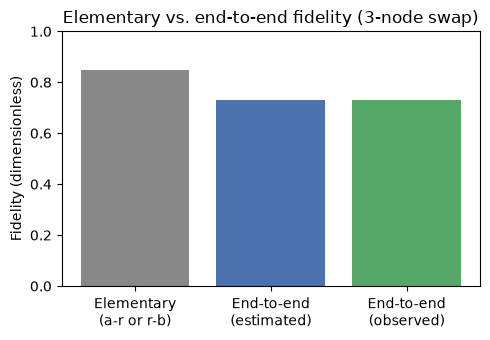

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 3.5))
labels = ["Elementary\n(a-r or r-b)", "End-to-end\n(estimated)", "End-to-end\n(observed)"]
values = [RAW_FIDELITY, plan.estimated_metrics.fidelity, observed_avg_fidelity]
ax.bar(labels, values, color=["#888888", "#4C72B0", "#55A868"])
ax.set_ylabel("Fidelity (dimensionless)")
ax.set_ylim(0, 1)
ax.set_title("Elementary vs. end-to-end fidelity (3-node swap)")
fig.tight_layout()
plt.show()


In [6]:
assert abs(observed_avg_fidelity - plan.estimated_metrics.fidelity) < 0.01, (
    "observed end-to-end fidelity should match the planner's pre-simulation estimate closely "
    "when no purification is involved"
)
assert pairs_df["fidelity"].max() <= plan.estimated_metrics.fidelity + 1e-9, (
    "no delivered pair can exceed the closed-form swap fidelity: waiting in memory only lowers it"
)
print("Planner estimate matches observed fidelity within tolerance.")
print(f"Distinct delivered fidelity values: {pairs_df['fidelity'].nunique()} "
      f"(min {pairs_df['fidelity'].min():.4f}, max {pairs_df['fidelity'].max():.4f}) - read from each pair's state.")

Planner estimate matches observed fidelity within tolerance.
Distinct delivered fidelity values: 351 (min 0.7212, max 0.7292) - read from each pair's state.


## Interpretação
A fidelidade elementar (0.85, igual à `raw_fidelity` configurada) é maior
que a fidelidade fim a fim: o swap em `r` combina dois pares imperfeitos.
No formalismo Bell-diagonal, com portas e medições ideais, o parâmetro de
Werner de cada par, `w = (4F - 1)/3 = 0.8`, se multiplica - `w = 0.64`,
isto é, `F = (1 + 3w)/4 = 0.73`. A estimativa do planner (calculada
*antes* de qualquer simulação, em `planning/feasibility.py`) usa essa
fórmula fechada. O valor observado fica um pouco abaixo e varia de par
para par: cada par elementar espera na memória até o outro enlace ficar
pronto, e nesse intervalo decoere. A estimativa não modela esse tempo de
espera - é uma fonte física de erro entre planejador e rede, pequena aqui
(tempo de coerência de 1 s, esperas de milissegundos) e maior quando os
pares esperam mais (`docs/physical_model.md`).

## Limitações
- Portas e medições ideais são o padrão desta topologia de demonstração;
  com `gate_fidelity`/`measurement_fidelity` menores que 1 o swap perde
  mais fidelidade (`ibqn.physics.bds_swap_fidelity`), e as campanhas do
  artigo usam valores de hardware da literatura
  (`docs/parameter_calibration.md`).
- A ordem do swap é decidida internamente pelo SeQUeNCe
  (`ResourceManager.generate_load_rules`) e não é parametrizável nesta
  versão; nesta cadeia há um único swap, então a questão não se coloca.
- Esta demonstração usa `min_fidelity` abaixo do teto de um único swap, de
  propósito, para isolar a física do swapping da purificação (ver o
  próximo notebook).

## Conclusão
Entrelaçamento fim a fim demonstrado numa cadeia de 3 nós, com a
estimativa do planner e o valor realmente observado na simulação
concordando dentro de tolerância pequena - e a diferença entre os dois
explicada pela decoerência durante a espera.